<center>
<font size="6"><strong> Progetto Statistical Learning</strong></font><br>
</center>

**INDICE**

<ol>
    <li>Introduzione
    <li>Raccolta dati
        <ol>
            2.1 Primi passi<br>
            2.2 Raccolta dati MusicBrainz<br>
            2.3 Raccolta features AcousticBrainz<br>
        </ol>
    </li>
    </ol>

# Introduzione

Nel contesto contemporaneo dell’industria musicale globale, il successo di una canzone non è
più riconducibile solamente alla sua qualità o alla fama dell’artista, ma è il risultato
dell’interazione di molteplici fattori: musicali, culturali, sociali e di marketing. La crescente
influenza delle piattaforme di streaming e delle dinamiche virali dei social media ha
radicalmente trasformato le modalità con cui una canzone può emergere e affermarsi nelle
classifiche. In questo scenario, diventa particolarmente interessante interrogarsi su quali siano
le caratteristiche che rendono un brano musicale una “hit” e, soprattutto, se sia possibile
prevedere il suo successo in anticipo. Questo progetto nasce proprio con l’intento di affrontare tale sfida. In
particolare, ci avvaliamo della Conformal Prediction, una tecnica potente nell’ambito
dell’apprendimento automatico, che ha il grande vantaggio di affiancare alla previsione anche
una misura esplicita dell’incertezza, garantendo margini di affidabilità statisticamente
controllabili.
Per lo sviluppo di questo progetto adottiamo un approccio data-over-method, in cui l’enfasi
principale è posta sulla qualità e ricchezza del dato piuttosto che sulla complessità del modello
utilizzato; di conseguenza la fase di raccolta dei dati e di costruzione del dataset assume un
ruolo centrale, poiché l’efficacia e l’affidabilità del modello predittivo dipendono direttamente
dalla solidità e dalla varietà delle informazioni disponibili.

# Raccolta dati

Come accennato in precedenza, applicando un approccio data-over-method, il focus del
progetto riguarda il processo di raccolta e costruzione del dataset, basandosi sull’idea che anche
modelli predittivi relativamente semplici possano fornire risultati efficaci, a patto che siano
alimentati da dati ricchi, accurati e ben strutturati.
Per questo motivo, abbiamo ritenuto fondamentale documentare e presentare nel dettaglio tutti
i passaggi affrontati durante la data acquisition, comprese le difficoltà incontrate e i tentativi
non andati a buon fine, che hanno comunque contribuito alla costruzione del dataset finale.

## Primi passi

La nostra strategia iniziale è stata quella di integrare un’interfaccia di programmazione messa
a disposizione direttamente da Spotify, denominata Spotify API, che consente agli utenti di
accedere a dati pubblici relativi ai brani, artisti, album presenti sulla piattaforma.
Tramite questi strumenti volevamo raccogliere numerosi
metadati come:
* Titolo della canzone
* Nome dell’artista principale
* Album di appartenenza
* Popolarità della canzone
* Popolarità dell’artista
* Data di rilascio del brano
* Durata della traccia (in millisecondi)
* Numero di follower dell’artista
* Genere associato all’artista

Ed anche altre features di stampo tecnico-acustico riguardanti i brani, come:
* Danceability
* Energy
* Loudness
* Speechiness
* Acousticness
* Instrumentalness
* Liveness
* Valence
* Tempo
* Key, mode, time_signature.

Per poter effettuare queste richieste era necessario, come primo passo, creare un’applicazione
sul sito *Spotify for developers*, al fine di ottenere le credenziali di accesso **CLIENT_ID** e
**CLIENT_SECRET**, le quali consentono l’autenticazione e l’interazione con l’API di Spotify.
Di seguito viene mostrato un esempio di codice per poter estrarre 50 canzoni casuali dell'anno
2020 e prenderne le features:

```python
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id="TUO_CLIENT_ID",
    client_secret="TUO_CLIENT_SECRET"))

results = sp.search(q='year:2020', type='track', limit=50)
for track in results['tracks']['items']:
    audio_features = sp.audio_features(track['id'])[0]
```

Le righe iniziali del codice si sono rivelate fondamentali per l'autenticazione e
l'identificazione dell'applicazione, mentre quelle successive contenevano la query necessaria
per l'estrazione delle informazioni desiderate.
Tuttavia, fin da subito abbiamo riscontrato un primo ostacolo: il codice restituiva un errore
relativo alla libreria Spotipy. Trattandosi inizialmente di una prova, non abbiamo
approfondito il problema e abbiamo deciso di proseguire direttamente con l'implementazione
del codice principale, riportato di seguito:


```python
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import time

# Autenticazione
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id='TUO_CLIENT_ID',
    client_secret='TUO_CLIENT_SECRET'))

# Parametri
year = 2020
genres = ['hip-hop', 'pop', 'rock', 'edm', 'r-n-b']
market = 'US'
tracks_per_genre = 200

# Ciclo for per estrarre le features delle canzoni
def get_recommendations_by_genre(genre, year, limit_tot):
    tracks = []
    seen_ids = set()

    while len(tracks) < limit_tot:
        try:
            recs = sp.recommendations(seed_genres=[genre], limit=100,
                                       market=market,
                                       min_popularity=20)
        except Exception as e:
            print(f"Errore su genere {genre}: {e}")
            break

        for track in recs['tracks']:
            track_id = track['id']
            if track_id in seen_ids:
                continue
            seen_ids.add(track_id)

            try:
                artist_id = track['artists'][0]['id']
                artist = sp.artist(artist_id)
                features = sp.audio_features(track_id)[0]
            except:
                continue

            if features and track['album']['release_date'].startswith(str(year)):
                track_data = {
                    'genre': genre,
                    'track_name': track['name'],
                    'track_id': track_id,
                    'artist_name': track['artists'][0]['name'],
                    'artist_id': artist_id,
                    'artist_followers': artist['followers']['total'],
                    'popularity': track['popularity'],
                    'release_date': track['album']['release_date'],
                    'danceability': features['danceability'],
                    'energy': features['energy'],
                    'speechiness': features['speechiness'],
                    'acousticness': features['acousticness'],
                    'instrumentalness': features['instrumentalness'],
                    'valence': features['valence'],
                    'tempo': features['tempo'],
                    'duration_ms': features['duration_ms']
                }
                tracks.append(track_data)

        time.sleep(0.5)

    return tracks[:limit_tot]

# Esecuzione
all_tracks = []
for genre in genres:
    print(f"Scarico tracce per il genere: {genre}")
    genre_tracks = get_recommendations_by_genre(genre, year, tracks_per_genre)
    all_tracks.extend(genre_tracks)
    print(f" -> Trovate {len(genre_tracks)} tracce\n")
```

Dopo la fase di autenticazione, il codice è stato progettato per estrarre 200 brani per ciascuno
dei cinque generi musicali selezionati, ossia:
* Hip-Hop
* Rock
* R&B
* Edm
* Pop

limitando la ricerca al solo mercato statunitense e
all’anno 2020. L’idea alla base era quella di eseguire lo script separatamente per cinque anni
diversi, in modo da ottenere un dataset complessivo di circa 10.000 osservazioni, ciascuna
associata alle relative feature estratte da Spotify.
Tuttavia, nel momento in cui abbiamo avviato l'esecuzione, il codice ha iniziato a restituire
errori, impedendoci di portare a termine correttamente la raccolta dei dati.

```python
Errore su genere rock: http status: 404, code: -1 - https://api.spotify.com/v1/recommendations?limit=100&seed_genres=rock&min_popularity=20:
 None, reason: None
```
Abbiamo quindi pensato che il *Rock* non fosse accettato fra i generi, pertanto abbiamo fatto girare la seguente riga di codice che stampa i generi presenti su Spotify:
```python
print(sp.recommendation_genre_seeds())
```

Tuttavia, questa riga di codice restituiva il seguente errore:
```python
HTTP Error for GET to https://api.spotify.com/v1/recommendations/available-genre-seeds with Params: {} returned 404 due to None
Traceback (most recent call last):
  File "/Users/guidodesimone/Desktop/pythonProject/venv/lib/python3.12/site-packages/spotipy/client.py", line 274, in _internal_call
    response.raise_for_status()
  File "/Users/guidodesimone/Desktop/pythonProject/venv/lib/python3.12/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 404 Client Error: Not Found for url: https://api.spotify.com/v1/recommendations/available-genre-seeds

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/guidodesimone/Desktop/pythonProject/Prova.py", line 11, in <module>
    print(sp.recommendation_genre_seeds())
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/guidodesimone/Desktop/pythonProject/venv/lib/python3.12/site-packages/spotipy/client.py", line 1771, in recommendation_genre_seeds
    return self._get("recommendations/available-genre-seeds")
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/guidodesimone/Desktop/pythonProject/venv/lib/python3.12/site-packages/spotipy/client.py", line 324, in _get
    return self._internal_call("GET", url, payload, kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/guidodesimone/Desktop/pythonProject/venv/lib/python3.12/site-packages/spotipy/client.py", line 294, in _internal_call
    raise SpotifyException(
spotipy.exceptions.SpotifyException: http status: 404, code: -1 - https://api.spotify.com/v1/recommendations/available-genre-seeds:
 None, reason: None
```

Resitutiva il codice 404, il che era un problema perché su Spotify c'era scritto chiaramente che potevamo ottenere i seguenti errori:
* 401
* 403
* 429

Abbiamo quindi pensato che in realtà il problema fosse a monte, nella fase di autenticazione. Così abbiamo letto nuovamente la documentazione di Spotify e quella di Spotipy, ma il processo sembrava essere corretto. Il dubbio era sull'uso di un Token generato da Spotify e valido un'ora, tuttavia, cercando sulla documentazione della libreria abbiamo visto che il Token veniva gestito in modo automatico, richiedendolo da solo se superata un ora oppure se fatta richiesta.

Abbiamo quindi provato a riscaricare la libreria, a mettere altri generi, a creare un'altra applicazione con credenziali diverse, a generare manualmente un nuovo Token. Non ha funzionato nulla di tutto questo. Abbiamo provato per diverso tempo a modificare il codice in moltissimi modi, ma l'errore permaneva.

Ad un certo punto abbiamo provato a semplificare di molto il codice, cercando le caratteristiche di una sola canzone, tuttavia, ci restituiva l'errore 403.

Questo errore ci ha portato fuori strada, in quanto il codice di stato 403 indica che non disponiamo
dei permessi necessari per accedere a quanto richiesto. Abbiamo dunque ipotizzato si trattasse di
un problema legato all'autenticazione e, come tentativo successivo, provato a
effettuare l’identificazione manuale tramite protocollo OAuth2. Tuttavia, anche questo
approccio si è rivelato inefficace.
Solo in un secondo momento siamo arrivati al punto di svolta. Esaminando con maggiore
attenzione la documentazione ufficiale di Spotify, ci siamo accorti che alcune delle funzioni di
nostro interesse risultavano contrassegnate con la dicitura “Deprecated”. Questo termine indica
che la funzione è obsoleta e non più supportata.
Abbiamo quindi scoperto che molte delle
funzioni di nostro interesse relative alle caratteristiche audio (come la dancability, energy,
acusticness etc) sono state ufficialmente rimosse da Spotify.
Questa modifica ha avuto un impatto significativo sul nostro progetto, poiché le informazioni
rimosse costituivano la base descrittiva su cui avremmo costruito il modello predittivo.

A questo punto, abbiamo valutato di prendere su Spotify solo le seguenti variabili, le cui funzioni erano ancora disponibili:
* Titolo della canzone
* Nome dell’artista principale
* Album di appartenenza
* Label discografica
* Popolarità della canzone
* Popolarità dell’artista
* Data di rilascio del brano
* Durata della traccia (in millisecondi)
* Numero di follower dell’artista
* Genere associato all’artista

Il codice per fare questo è il seguente:
```python
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import time
import pandas as pd

# Credenziali
client_id = "CLIENT-ID"
client_secret = "CLIENT-SECRET"

# Autenticazione
auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(auth_manager=auth_manager)

# Lista dei nomi degli artisti
artist_names = []


# Risultati finali
albums_data = []

for name in artist_names:
    try:
        print(f"\nRicerca artista: {name}")

        # Ricerca artista
        result = sp.search(q='artist:' + name, type='artist', limit=1)
        if not result['artists']['items']:
            print(f"Nessun artista trovato per: {name}")
            continue

        artist = result['artists']['items'][0]
        artist_id = artist['id']
        artist_name = artist['name']  

        # Ciclo for per raccolta album
        albums = sp.artist_albums(artist_id=artist_id, album_type='album', limit=50)
        seen = set()

        for album in albums['items']:
            album_id = album['id']
            if album_id in seen:
                continue
            seen.add(album_id)

            # Dettagli dell’album
            full_album = sp.album(album_id)
            album_name = full_album['name']
            release_date = full_album['release_date']
            label = full_album.get('label', 'N/A')

            albums_data.append({
                'ID Album': album_id,
                'Artista': artist_name,
                'Nome Album': album_name,
                'Data Rilascio': release_date,
                'Label': label
            })

        time.sleep(1)

    except Exception as e:
        print(f"Errore con artista {name}: {e}")
        continue

# Salva in Excel
df = pd.DataFrame(albums_data)
df.to_excel("album_artisti.xlsx", index=False, engine='openpyxl')
print("\nSalvataggio completato: album_artisti.xlsx")
```

Nel codice sopra, dopo l'autenticazione, è presente sia la lista con gli artisti da noi scelti sia il ciclo for tramite il quale abbiamo recuperato tutte le informazioni relative agli album, ossia:
* Artista
* Nome album
* Data Rilascio
* Label.

Dopo aver recuperato le informazioni sopra, tramite un altro codice abbiamo preso i dati realativi agli artisti, ossia:
* Nome
* Popolarità
* Follower
* Generi

Il codice usato è il seguente:
```python
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import time

# Autenticazione
client_id = "CLIENT-ID"
client_secret = "CLIENT-SECRET"
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(client_id=client_id, client_secret=client_secret))


def get_artist_info(artist_name):
    try:
        results = sp.search(q=f"artist:{artist_name}", type='artist', limit=3)
        items = results['artists']['items']

        if not items:
            print(f"Artista non trovato: {artist_name}")
            return None

        artist = items[0]
        return {
            'Nome': artist_name,
            'ID': artist['id'],
            'Popolarità': artist['popularity'],
            'Follower': artist['followers']['total'],
            'Generi': ", ".join(artist['genres']) if artist['genres'] else "N/A"
        }

    except spotipy.exceptions.SpotifyException as e:
        print(f"Errore Spotify con artista '{artist_name}': {e}")
        return None
    except Exception as ex:
        print(f"Errore generale con artista '{artist_name}': {ex}")
        return None


# Lista di nomi di artisti
nomi_artisti = []


artisti_info = []
for i, nome in enumerate(nomi_artisti):
    print(f"🔍 Elaboro artista {i+1}/{len(nomi_artisti)}: {nome}")
    info = get_artist_info(nome)
    if info:
        artisti_info.append(info)
    time.sleep(0.2)

# Salvo in Excel
df_artisti = pd.DataFrame(artisti_info)
df_artisti.to_excel("artisti_info.xlsx", index=False, engine="openpyxl")
print("\nInformazioni sugli artisti salvate in 'artisti_info.xlsx'")
```

Dopodiché, tramite un terzo codice abbiamo reperito la durata delle canzoni:
```python
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import time

# Autenticazione
client_id = "CLIENT-ID"
client_secret = "CLIENT-SECRET"
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(client_id=client_id, client_secret=client_secret))

# Carica lista di album_id e nome album
df_album = pd.read_excel("album_artisti.xlsx")
album_list = df_album[['ID Album', 'Nome Album', 'Artista']].drop_duplicates()

# Lista risultati
track_data = []

for idx, row in album_list.iterrows():
    album_id = row['ID Album']
    album_name = row['Nome Album']
    artist_name = row['Artista']

    try:
        album_tracks = sp.album_tracks(album_id)

        for track in album_tracks['items']:
            track_id = track['id']
            track_name = track['name']
            duration_ms = track['duration_ms']
            track_artists = ", ".join([a['name'] for a in track['artists']])

            track_data.append({
                'ID Canzone': track_id,
                'Nome Canzone': track_name,
                'Durata (ms)': duration_ms,
                'Artista': track_artists,
                'Album': album_name,
                'ID Album': album_id,
                'Artista Album': artist_name
            })

        if idx % 50 == 0:
            print(f"Elaborati {idx+1} album su {len(album_list)}")
        time.sleep(0.5)

    except Exception as e:
        print(f"Errore con album {album_name} ({album_id}): {e}")
        continue

# Crea DataFrame
df_tracks = pd.DataFrame(track_data)

# Rimuovi canzoni duplicate
df_tracks_clean = df_tracks.drop_duplicates(subset=['Nome Canzone', 'Durata (ms)', 'Artista'])

# Salva su Excel
df_tracks_clean.to_excel("tracce_uniche_albumV2.2.xlsx", index=False, engine="openpyxl")
print("File Excel salvato: tracce_uniche_albumV2.2.xlsx")
```

Infine, tramite un ultimo codice abbiamo preso altre informazioni sulle canzoni, vale a dire se una determinata canzone è esplicita oppure no e la sua popolarità:
```python
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import requests
import pandas as pd
import time
import os

# Autenticazione Spotify
client_id = 'CLIENT-ID'
client_secret = 'SECRET-ID'

auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)

# Retry automatico per 429, 500, 502, 503, 504
retry_strategy = Retry(
    total=5,
    backoff_factor=2,
    status_forcelist=[429, 500, 502, 503, 504],
    raise_on_status=False
)
adapter = HTTPAdapter(max_retries=retry_strategy)
session = requests.Session()
session.mount("https://", adapter)

sp = spotipy.Spotify(auth_manager=auth_manager, requests_session=session)

# Carica dati già processati
if os.path.exists("canzoni_info_batch.xlsx"):
    df_esistenti = pd.read_excel("canzoni_info_batch.xlsx")
    ids_gia_fatti = set(df_esistenti['ID Canzone'].dropna().tolist())
else:
    df_esistenti = pd.DataFrame()
    ids_gia_fatti = set()

# Carica la lista completa delle canzoni
df_tutte = pd.read_excel("tracce_uniche_album.xlsx")
ids_tutte = set(df_tutte['ID Canzone'].dropna().tolist())

# Determina quali canzoni mancano
ids_mancanti = list(ids_tutte - ids_gia_fatti)
print(f"Totale canzoni: {len(ids_tutte)}")
print(f"Già analizzate: {len(ids_gia_fatti)}")
print(f"Da elaborare: {len(ids_mancanti)}")


# Funzione per dividere in blocchi da 50
def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]


# Ciclo principale
track_info = df_esistenti.to_dict('records')  # carica i dati esistenti

for i, chunk in enumerate(chunks(ids_mancanti, 50)):
    print(f"\nElaboro blocco {i + 1}/{len(ids_mancanti) // 50} (canzoni analizzate finora: {len(track_info)})")

    success = False
    tentativi = 0

    while not success and tentativi < 5:
        try:
            print(f"Richiedo dettagli per 50 canzoni (blocco {i + 1})...")
            response = sp.tracks(chunk)

            if response is None or 'tracks' not in response or response['tracks'] is None:
                print(f"Risposta nulla o malformata dal blocco {i + 1}, salto...")
                break

            for track in response['tracks']:
                if track is None:
                    print("Track nulla, salto.")
                    continue
                track_info.append({
                    'ID Canzone': track['id'],
                    'Nome Canzone': track['name'],
                    'Esplicita': track['explicit'],
                    'Popolarità': track['popularity']
                })
                print(f"Aggiunta: {track['name']} | ID: {track['id']}")

            success = True

        except spotipy.exceptions.SpotifyException as e:
            if e.http_status == 429:
                retry_after = int(e.headers.get("Retry-After", 60))
                print(f"\nRATE LIMIT: attendo {retry_after} secondi per blocco {i + 1}...\n")
                for r in range(retry_after, 0, -1):
                    print(f"Riprendo in {r} sec...", end="\r")
                    time.sleep(1)
                print("\nFine attesa, riprendo...")
            else:
                print(f"SpotifyException nel blocco {i + 1}: {e}")
                break

        except Exception as ex:
            tentativi += 1
            print(f"Errore generico nel blocco {i + 1}, tentativo {tentativi}/5: {ex}")
            time.sleep(5)

    if (i + 1) % 10 == 0:
        df_partial = pd.DataFrame(track_info)
        df_partial.to_excel("canzoni_info_batch.xlsx", index=False, engine="openpyxl")
        print(f"Salvataggio intermedio: {len(track_info)} canzoni salvate")

    time.sleep(0.3)  # piccolo delay tra batch

# Salvataggio finale
df_finale = pd.DataFrame(track_info)
df_finale.to_excel("canzoni_info_completo.xlsx", index=False, engine="openpyxl")
print("Script completato! File salvato: canzoni_info_completo.xlsx")
```

A questo punto, l'attività svolta tramite l'API di Spotify si è conclusa con successo, portando alla creazione di un dataset contenente circa 14.000 brani musicali.

## Raccolta dati MusicBrainz

Come alternativa a Spotify, abbiamo scelto di utilizzare AcousticBrainz, un servizio che consente di ottenere informazioni avanzate (low-level features) relative alle caratteristiche audio di un brano musicale. Tuttavia, per poter accedere a tali informazioni tramite l'API di AcousticBrainz, è stato necessario prima identificare in modo univoco ciascun brano. A tal fine, ci siamo avvalsi di un'ulteriore piattaforma, MusicBrainz, dalla quale abbiamo recuperato i codici identificativi univoci delle canzoni (MBID) utilizzando la relativa API.

Il codice utilizzato è stato il seguente:
```python
import pandas as pd
import requests
import time
import os
import re


# Dati iniziali
input_file = 'Dataset.xlsx'
output_file = 'Dataset_MBID.xlsx'
batch_size = 300
sleep_time = 1.0
user_agent = 'Inserire user_agent'


# Normalizzazione testo


def pulisci_testo(testo):
    if pd.isna(testo):
        return ''

    # Minuscolo
    testo = testo.lower()

    # Rimpiazza apostrofi curvi con quello normale
    testo = testo.replace("’", "'").replace("‘", "'")

    # Rimuovi informazioni tra parentesi (es. "Live", "Remastered", "feat." etc.)
    testo = re.sub(r'\(.*?\)', '', testo)

    # Rimuovi indicazioni tipo feat., remastered, live, version, edit
    testo = re.sub(r'\b(feat\.?|featuring|remaster(ed)?|live|edit|version)\b', '', testo)

    # Mantieni lettere accentate, numeri e simboli utili, togli solo il rumore (emoji, caratteri strani)
    testo = re.sub(r"[^\w\s'\-\/\\:,\.!?\&àèéìòùáíóúâêîôûäëïöüñç]", '', testo)

    # Rimpiazza più spazi con uno solo
    testo = re.sub(r'\s+', ' ', testo)

    return testo.strip()


# Ricerca codice
def get_recording_mbid(title, artist):
    try:
        query = f'recording:"{title}" AND artist:"{artist}"'
        url = f'https://musicbrainz.org/ws/2/recording/?query={query}&fmt=json'
        headers = {'User-Agent': user_agent}
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if 'recordings' in data and len(data['recordings']) > 0:
                return data['recordings'][0]['id']
        return None
    except Exception as e:
        print(f"[!] Errore durante la richiesta per '{title}' - '{artist}': {e}")
        return None


# Caricamento dati
print("Caricamento del dataset...")

if os.path.exists(output_file):
    print("File esistente trovato. Riprendo da dove avevo lasciato.")

    df_processed = pd.read_excel(output_file)
    df_processed.loc[df_processed['MBID'].isna(), 'Canzone_pulita'] = df_processed['Canzone'].apply(pulisci_testo)
    df_processed.loc[df_processed['MBID'].isna(), 'Artista_pulito'] = df_processed['Artista'].apply(pulisci_testo)
else:
    print("Creo nuovo dataset pulito.")
    df = pd.read_excel(input_file)
    df['MBID'] = None
    df['Canzone_pulita'] = df['Canzone'].apply(pulisci_testo)
    df['Artista_pulito'] = df['Artista'].apply(pulisci_testo)
    df_processed = df


# Elaborazione automatica
start_index = df_processed[df_processed['MBID'].isna()].index.min()
if pd.isna(start_index):
    print("Tutte le canzoni hanno già un MBID!")
    exit()

total_len = len(df_processed)
while start_index < total_len:
    end_index = min(start_index + batch_size, total_len)
    print(f"\nElaborazione canzoni da riga {start_index} a {end_index - 1}...\n")

    for i in range(start_index, end_index):
        titolo = df_processed.at[i, 'Canzone_pulita']
        artista = df_processed.at[i, 'Artista_pulito']
        print(f"[{i+1}] Ricerca: '{titolo}' di '{artista}'")

        mbid = get_recording_mbid(titolo, artista)
        df_processed.at[i, 'MBID'] = mbid

        if mbid:
            print(f"MBID trovato: {mbid}")
        else:
            print("Nessun MBID trovato.")

        time.sleep(sleep_time)

    # Salvataggio intermedio
    print("\nSalvataggio dei risultati...")
    df_processed.to_excel(output_file, index=False)

    # Statistiche
    parziale = df_processed.iloc[start_index:end_index]
    trovati = parziale['MBID'].notna().sum()
    non_trovati = batch_size - trovati
    percentuale = (trovati / batch_size) * 100

    print(f"\nSTATISTICHE BATCH:")
    print(f"MBID trovati: {trovati}")
    print(f"Non trovati: {non_trovati}")
    print(f"Percentuale successo: {percentuale:.2f}%")

    start_index = end_index

print("\nTutte le canzoni sono state elaborate!")
```

Il codice presentato si apre con la definizione di una funzione dedicata alla normalizzazione del testo, un passaggio rivelatosi fondamentale. In una versione iniziale, infatti, tale funzionalità era assente, con la conseguenza che il numero di canzoni correttamente individuate risultava sensibilmente inferiore rispetto a quelle ottenute tramite Spotify.

Segue una fase di caricamento dei dati, necessaria per consentire la ripresa del lavoro da salvataggi intermedi. Questa strategia si è resa indispensabile poiché il dataset conteneva oltre 14.000 canzoni, e l'API utilizzata consentiva una sola richiesta al secondo. Di conseguenza, anche nella migliore delle ipotesi, sarebbero stati necessari più di 14.000 secondi solo per l'attesa tra una richiesta e l'altra, senza considerare i tempi di elaborazione e risposta.

A seguire, il codice implementa una funzione per la ricerca dell'MBID (MusicBrainz Identifier), che consente di ottenere il codice identificativo univoco di ciascun brano a partire dal nome della canzone e dell'artista (informazioni fornite da Spotify).

Infine, il codice produce alcune statistiche riassuntive sull'esito della ricerca, utili per valutare l'efficacia del processo, e conclude con un salvataggio finale dei risultati.

Durante questa fase del progetto, abbiamo riscontrato una discrepanza significativa tra il numero di canzoni ottenute tramite Spotify e quelle effettivamente recuperabili tramite l'API di MusicBrainz: solo circa la metà dei brani iniziali risultava infatti disponibile su quest'ultima piattaforma. Questo problema era dovuto principalmente al fatto che non tutte le versioni dei brani presenti su Spotify sono registrate in modo corrispondente su MusicBrainz, in particolare nel caso di versioni remastered, live o con titoli leggermente diversi.

Per ovviare a questa limitazione, abbiamo deciso di ampliare il nostro campione introducendo nuovi artisti, selezionati anch'essi tra i più noti a livello internazionale. Per ciascuno di essi abbiamo ripetuto l'intera procedura di raccolta dati tramite l'API di Spotify, ottenendo in questo modo circa 7.000 nuove canzoni. Abbiamo poi cercato anche queste su MusicBrainz, riuscendo così ad arricchire ulteriormente il dataset.

Al termine di questo processo di integrazione, siamo riusciti a ottenere un dataset finale composto da circa 12.000 canzoni per le quali erano disponibili sia le informazioni base di Spotify che gli MBID.




## Raccolta features AcousticBrainz

Una volta ottenuti gli MBID tramite MusicBrainz, siamo riusciti ad accedere ai brani presenti anche su AcousticBrainz. Questo ci ha permesso di recuperare alcune informazioni audio aggiuntive per ciascuna canzone.

Inizialmente, l'obiettivo era quello di ottenere delle caratteristiche simili a quelle fornite da Spotify (come ad esempio danceability, energy, ecc.), tuttavia abbiamo constatato che tali features non erano disponibili su AcousticBrainz. Al loro posto, la piattaforma mette a disposizione le cosiddette "high-level features", ovvero caratteristiche derivate da modelli di machine learning addestrati su un ampio numero di tracce.

Purtroppo, essendo queste ultime parte di un progetto collaborativo basato su contributi della community, risultavano disponibili solo per un numero molto limitato di brani, rendendole inutilizzabili per il nostro scopo.

Per questa ragione, abbiamo deciso di orientarci sulle “low-level features”, ovvero caratteristiche audio calcolate direttamente dal segnale acustico, disponibili in modo più sistematico e uniforme. Nello specifico, abbiamo selezionato le seguenti variabili:

* average_loudness: livello medio del volume percepito del brano (in dB);
* pitch_salience_mean: misura media della chiarezza tonale;
* spectral_centroid_mean: media del centroide spettrale, legato alla brillantezza del suono;
* spectral_flux_mean: misura media della variazione spettrale nel tempo;
* spectral_complexity_mean: valore medio della complessità spettrale;
* hfc_mean: media dell'energia contenuta nelle alte frequenze (High Frequency Content);
* mfcc_0_mean: media del primo coefficiente MFCC, che rappresenta l'energia complessiva del segnale audio;
* mfcc_1_mean: media del secondo coefficiente MFCC, legato alla pendenza spettrale del brano;
* mfcc_2_mean: media del terzo coefficiente MFCC, associato alla curvatura dello spettro;
* mfcc_3_mean: media del quarto coefficiente MFCC, utile per descrivere variazioni timbriche più complesse.

Il codice per fare quanto detto è il seguente:
```python
import time
import requests
import pandas as pd
import os

# Configurazione
input_file = "Dataset_finale_Spotify.xlsx"  # file con colonna 'MBID'
output_file = "low_level_features_final.xlsx"
checkpoint_prefix = "low_level_features_checkpoint_"
batch_save = 300
rate_limit_seconds = 1.1
user_agent = "Inserire user agent"

headers = {"User-Agent": user_agent}

# Funzione per ottenere le features
def fetch_low_level(mbid):
    url = f"https://acousticbrainz.org/api/v1/{mbid}/low-level"
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        if resp.status_code != 200:
            return None
        data = resp.json()
        low = data.get("lowlevel", {})

        return {
            "mbid": mbid,
            "average_loudness": low.get("average_loudness"),
            "bpm": low.get("bpm"),
            "onset_rate": low.get("onset_rate"),
            "pitch_salience_mean": low.get("pitch_salience", {}).get("mean"),
            "spectral_centroid_mean": low.get("spectral_centroid", {}).get("mean"),
            "spectral_flux_mean": low.get("spectral_flux", {}).get("mean"),
            "spectral_complexity_mean": low.get("spectral_complexity", {}).get("mean"),
            "hfc_mean": low.get("hfc", {}).get("mean"),
            "mfcc_0_mean": low.get("mfcc", {}).get("mean", [None]*13)[0],
            "mfcc_1_mean": low.get("mfcc", {}).get("mean", [None]*13)[1],
            "mfcc_2_mean": low.get("mfcc", {}).get("mean", [None]*13)[2],
            "mfcc_3_mean": low.get("mfcc", {}).get("mean", [None]*13)[3],
        }
    except Exception as e:
        print(f"[!] Errore durante la richiesta per {mbid}: {e}")
        return None

# Caricamento MBID
df_input = pd.read_excel(input_file)
df_input = df_input.dropna(subset=["MBID"])
df_input["MBID"] = df_input["MBID"].astype(str)
mbids = df_input["MBID"].tolist()

# Ripresa da salvataggio parziale se esiste
features = []
start_idx = 0
found = 0
not_found = 0

checkpoint_files = [f for f in os.listdir() if f.startswith(checkpoint_prefix) and f.endswith(".xlsx")]
if checkpoint_files:
    checkpoint_files.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    last_checkpoint = checkpoint_files[0]
    print(f"Riprendo da checkpoint: {last_checkpoint}")
    df_checkpoint = pd.read_excel(last_checkpoint)
    features = df_checkpoint.to_dict(orient="records")
    processed_mbids = [f["mbid"] for f in features if "mbid" in f]
    # Trova indice da cui ripartire (primo MBID non processato)
    for i, mbid in enumerate(mbids):
        # Per mantenere duplicati, controlliamo se quel MBID è già stato processato esattamente 'count' volte
        count_in_input = mbids[:i+1].count(mbid)
        count_in_processed = processed_mbids.count(mbid)
        if count_in_processed < count_in_input:
            start_idx = i
            break
    found = len(features)
else:
    print("Partenza da zero.")

total_mbids = len(mbids)

print(f"Inizio elaborazione da indice {start_idx} su {total_mbids} MBID totali\n")

for i in range(start_idx, total_mbids):
    mbid = mbids[i]
    result = fetch_low_level(mbid)
    if result:
        features.append(result)
        found += 1
        print(f"[{i+1}/{total_mbids}] Trovato: {mbid}")
    else:
        not_found += 1
        print(f"[{i+1}/{total_mbids}] Non trovato: {mbid}")

    if (i + 1) % batch_save == 0 or (i + 1) == total_mbids:
        print(f"\nCheckpoint a {i+1} MBID processati:")
        print(f"   trovati: {found}")
        print(f"   non trovati: {not_found}")

        df_save = pd.DataFrame(features)
        checkpoint_name = f"{checkpoint_prefix}{i+1}.xlsx"
        df_save.to_excel(checkpoint_name, index=False)
        print(f"Salvataggio checkpoint: '{checkpoint_name}'")

    time.sleep(rate_limit_seconds)

df_final = pd.DataFrame(features)
df_final.to_excel(output_file, index=False)

print(f"\nElaborazione completata!")
print(f"Totale trovati: {found}")
print(f"Totale non trovati: {not_found}")
print(f"File finale salvato in '{output_file}'")
```

La struttura di questo codice ricalca quella già utilizzata in precedenza per l'estrazione degli MBID. Anche in questo caso troviamo una funzione dedicata al recupero delle feature (quelle low-level descritte precedentemente), seguita dal caricamento degli MBID in una lista da cui partire per effettuare le richieste.

Come prima è presente un sistema di salvataggio intermedio pensato per poter riprendere l'elaborazione in caso di errori o interruzioni, a causa dei tempi di esecuzione molto lunghi (una richiesta al secondo).

Infine, il codice termina con una fase di riepilogo statistico, che consente di monitorare l'andamento della raccolta, e con il salvataggio finale del dataset risultante in un file Excel.

Il dataset risultante da questa fase conteneva circa 5.800 canzoni. Poiché ritenevamo il numero di canzoni non ancora sufficiente, abbiamo deciso di ampliarlo ripetendo tutti i passaggi fatti fino ad ora con ulteriori artisti internazionali.


# Analisi esplorativa dei dati

Come prima cosa importiamo le librerie necessarie per effettuare l'analisi esplorativa dei dati.

In [ ]:
# Importazione librerie
try:
  print('Importazione librerie in corso...')
  import numpy as np
  import pandas as pd
  import matplotlib.pyplot as plt
  import seaborn as sns
  print('Importazione completata.')
except Exception as e:
  print("Errore nell'importazione: \n")
  print(e)

Importazione librerie in corso...
Importazione completata.


## Informazioni preliminari

Dopo aver importato le librerie dobbiamo importare il dataset. Successivamente possiamo iniziare ad estrapolare delle informazioni su di esso e sulle variabili che contiene.

In [ ]:
# Importazione dataset
try:
  print('Importazione dataset...')
  df = pd.read_excel('Dataset_Finale.xlsx')
  print('Dataset importato correttamente')
except Exception as e:
  print(f'Errore {e}')
  print("Errore nel caricamento del dataset. Assicurati che sia caricato nella cartella di lavoro e che il nome o l'estensione siano corrette")

Importazione dataset...
Dataset importato correttamente


In [ ]:
# Visione del numero di osservazioni e del numero di features
print(f'Il dataset ha un totale di {df.shape[0]} osservazioni ed un totale di {df.shape[1]} colonne')

Il dataset ha un totale di 8592 osservazioni ed un totale di 22 colonne


In [ ]:
# Visualizzazione delle prime 10 righe del dataset
print('Le prime 5 righe del dataset sono le seguenti:\n')
df.head()

Le prime 5 righe del dataset sono le seguenti:



,MBID,Canzone,Artista,Album,Popolarità canzone,Popolarità canzone (numerico),Popolarità artista,Durata (millisecondi),Anno di uscita,Esplicita (si o no),...,average_loudness,pitch_salience_mean,spectral_centroid_mean,spectral_flux_mean,spectral_complexity_mean,hfc_mean,mfcc_0_mean,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean
0,d852eb53-f4a8-4433-8be4-dc8e231dd9fb,ATTENTION,Miley Cyrus,ATTENTION: MILEY LIVE,Media,39,86,95525,2022,False,...,0.934246,0.448877,1244.396240,0.117094,20.282139,22.034290,-666.303650,144.373627,-9.428632,17.377815
1,40d992ca-efe8-4610-99bd-071d7248a9bf,Plastic Hearts,Miley Cyrus,Plastic Hearts,Alta,67,86,205733,2020,False,...,0.900379,0.529124,1341.299194,0.095373,18.080109,24.376122,-650.792908,116.508080,9.645878,14.823727
2,c0274153-a3e8-4b11-81e6-f07275d16b15,Night Crawling (feat. Billy Idol),Miley Cyrus,Plastic Hearts,Alta,59,86,189013,2020,False,...,0.931439,0.508689,2045.376099,0.091148,25.562569,29.066114,-646.424805,96.730606,-3.659604,21.485662
3,7e50f188-d051-406d-bf51-8e535ca1b92a,Golden G String,Miley Cyrus,Plastic Hearts,Alta,52,86,235746,2020,False,...,0.635937,0.514471,1538.350586,0.068799,14.770874,21.185431,-710.900757,130.181366,-12.214740,-7.033721
4,10a98fa5-7c7d-4aee-9809-0e6a75d6c5fa,Heart Of Glass (Live from the iHeart Festival),Miley Cyrus,Plastic Hearts,Alta,68,86,213671,2020,False,...,0.936610,0.608384,1864.768921,0.091719,25.373158,29.560160,-614.902527,85.087837,-20.124908,13.393828


In [ ]:
# Visualizzazione del tipo di variabili
print('Le variabili presenti nel dataset sono del seguente tipo: \n')
df.dtypes

Le variabili presenti nel dataset sono del seguente tipo: 



,0
MBID,object
Canzone,object
Artista,object
Album,object
Popolarità canzone,object
Popolarità canzone (numerico),int64
Popolarità artista,int64
Durata (millisecondi),int64
Anno di uscita,int64
Esplicita (si o no),bool


Da questi due comandi possiamo notare subito che la durata di una canzone è espressa in millisecondi, tuttavia, per garantire un'interpretibilità maggiore la trasformiamo in minuti.

Oltre questo sono presenti alcune variabili che non hanno alcun potere predittivo, quindi le eliminiamo.
Esse sono:

* MBID, il quale è un codice identificativo;
* La canzone;
* L'artista;
* L'album;
* La popolarità canzone numerica, con valori da 0 a 100 (usiamo quella in classi);
* La durata in millisecondi, sostituita da quella in minuti.


In [ ]:
# Trasformazione della durata di una canzone da millisecondi in minuti
try:
  indice = df.columns.get_loc('Durata (millisecondi)')
  valore_durata_minuti = df['Durata (millisecondi)'] / 60000
  df.insert(loc=indice, column='Durata (minuti)', value=valore_durata_minuti)
  print('Variabile trasformata correttamente.')
except Exception as e:
  print(f'Errore: {e}')
  print('Errore nella trasformazione.')

Variabile trasformata correttamente.


In [ ]:
# Eliminazione variabili inutili ai fini del modello
def eliminazioni_colonne(colonne_da_eliminare):
  for i in colonne_da_eliminare:
    if i in df.columns:
      df.drop(i, axis=1, inplace=True)
      print(f'Colonna "{i}" eliminata correttamente.')
    else:
      print(f'La colonna "{i}" non è presente nel dataset. Controlla che il nome sia corretto.')



colonne_da_eliminare=['MBID', 'Canzone', 'Artista', 'Album', 'Popolarità canzone (numerico)',
          'Durata (millisecondi)']
eliminazioni_colonne(colonne_da_eliminare)

Colonna "MBID" eliminata correttamente.
Colonna "Canzone" eliminata correttamente.
Colonna "Artista" eliminata correttamente.
Colonna "Album" eliminata correttamente.
Colonna "Popolarità canzone (numerico)" eliminata correttamente.
Colonna "Durata (millisecondi)" eliminata correttamente.


In [ ]:
# Visualizzazione prime 5 righe del dataset per vedere se la durata in minuti è corretta e se le colonne sono
# state eliminate correttamente.
df.head()

,Popolarità canzone,Popolarità artista,Durata (minuti),Anno di uscita,Esplicita (si o no),Follower artista,Genere artista,average_loudness,pitch_salience_mean,spectral_centroid_mean,spectral_flux_mean,spectral_complexity_mean,hfc_mean,mfcc_0_mean,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean
0,Media,86,1.592083,2022,False,26113461,pop,0.934246,0.448877,1244.396240,0.117094,20.282139,22.034290,-666.303650,144.373627,-9.428632,17.377815
1,Alta,86,3.428883,2020,False,26113461,pop,0.900379,0.529124,1341.299194,0.095373,18.080109,24.376122,-650.792908,116.508080,9.645878,14.823727
2,Alta,86,3.150217,2020,False,26113461,pop,0.931439,0.508689,2045.376099,0.091148,25.562569,29.066114,-646.424805,96.730606,-3.659604,21.485662
3,Alta,86,3.929100,2020,False,26113461,pop,0.635937,0.514471,1538.350586,0.068799,14.770874,21.185431,-710.900757,130.181366,-12.214740,-7.033721
4,Alta,86,3.561183,2020,False,26113461,pop,0.936610,0.608384,1864.768921,0.091719,25.373158,29.560160,-614.902527,85.087837,-20.124908,13.393828


Possiamo ora riprendere con l'esplorazione del dataset. Visualizziamo quindi il numero di classi per le variabili categoriche presenti nel dataset, di cui una è la nostra target (Popolarità canzone) e continuiamo con la descrizione del dataset stesso.

In [ ]:
# Visualizzazione numero di classi variabili categoriche
def classi_var_cat(variabili_cat):
  for i in variabili_cat:
    if i in df.columns:
      num_classi = df[i].nunique()
      print(f'Il numero di classi della variabile "{i}" è {num_classi}')
    else:
      print('La variabile non è presente nel dataset. Assicurati di aver scritto il nome correttamente.')

variabili_cat = []
for col in df.columns:
  if df[col].dtype == 'object' or df[col].dtype == 'category':
    variabili_cat.append(col)

if not variabili_cat:
  print('Non ci sono variabili categoriche nel dataset.')
classi_var_cat(variabili_cat)

Il numero di classi della variabile "Popolarità canzone" è 4
Il numero di classi della variabile "Genere artista" è 6


In [ ]:
# Visualizzazioni statistiche descrittive variabili continue
print('Le principali statistiche descrittive delle variabili continue sono le seguenti: \n')
df.describe()

Le principali statistiche descrittive delle variabili continue sono le seguenti: 



,Popolarità artista,Durata (minuti),Anno di uscita,Follower artista,average_loudness,pitch_salience_mean,spectral_centroid_mean,spectral_flux_mean,spectral_complexity_mean,hfc_mean,mfcc_0_mean,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean
count,8592.000000,8592.000000,8592.000000,8.592000e+03,8592.000000,8592.000000,8592.000000,8592.000000,8592.000000,8592.000000,8592.000000,8592.000000,8592.000000,8592.000000
mean,78.879655,3.880273,2005.204609,2.003748e+07,0.796604,0.517227,1334.339671,0.088664,17.314640,45.152667,-681.402983,128.373073,1.305504,21.453564
std,9.934177,1.537278,16.285510,2.771226e+07,0.206749,0.064536,428.895422,0.025341,7.005819,78.185338,52.392054,29.591035,22.363336,14.148727
min,56.000000,0.058883,1957.000000,1.604680e+05,0.000142,0.178355,265.588531,0.022878,2.989610,3.429662,-950.048401,-1.505481,-172.078278,-55.690498
25%,71.000000,3.088829,1997.000000,3.423671e+06,0.742784,0.482335,1030.590363,0.072458,12.311126,16.897706,-708.584000,105.735382,-12.912579,12.242132
50%,80.000000,3.731017,2011.000000,1.009380e+07,0.878339,0.523802,1308.290283,0.086664,15.549132,22.227369,-676.722168,125.983818,1.280322,21.416023
75%,86.000000,4.471879,2018.000000,2.255130e+07,0.934305,0.560768,1617.925049,0.101578,21.098913,29.057391,-644.640701,149.478886,15.398260,30.406921
max,99.000000,38.046433,2025.000000,1.390000e+08,0.988522,0.725373,4408.857422,0.339612,43.166519,1557.986328,-568.412354,265.046844,99.243637,107.217178


## Spiegazione variabile target

Nel nostro studio, la variabile target è rappresentata dalla popolarità della canzone, un indice numerico compreso tra 0 e 100. Poiché l'obiettivo dell'analisi è affrontare un problema di classificazione, abbiamo trasformato questa variabile continua in una variabile categorica, suddividendola in quattro classi distinte:

* Bassa: punteggio compreso tra 0 e 25;
* Media: punteggio compreso tra 26 e 50;
* Alta: punteggio compreso tra 51 e 75;
* Hit: punteggio compreso tra 76 e 100.
L'indice di popolarità di un brano su Spotify non corrisponde a un semplice conteggio del numero di ascolti, bensì rappresenta una valutazione relativa della notorietà del brano sulla piattaforma. In particolare, è un indicatore sintetico che tiene conto di diversi aspetti del comportamento degli utenti, tra cui:

* il numero totale di ascolti del brano,
* la frequenza con cui viene aggiunto a playlist,
* il numero di salvataggi da parte degli utenti,
* la quantità di condivisioni,
* e altre metriche di coinvolgimento.

Spotify considera sia gli ascolti diretti (quelli attivati dall'utente) sia quelli generati automaticamente (ad esempio tramite playlist editoriali o algoritmiche). Un punteggio elevato indica, dunque, un livello di popolarità maggiore, che riflette sia una maggiore esposizione del brano sulla piattaforma che un più alto grado di interazione da parte degli utenti.


## Visualizzazione ed eliminazione dati mancanti

A questo punto possiamo controllare se ci sono o meno dei dati mancanti.

In [ ]:
# Visualizzazione valori mancanti nel dataset in termini assoluti
print('In termini assoluti i valori mancanti per variabile sono: \n')
df.isnull().sum()

In termini assoluti i valori mancanti per variabile sono: 



,0
Popolarità canzone,0
Popolarità artista,0
Durata (minuti),0
Anno di uscita,0
Esplicita (si o no),0
Follower artista,0
Genere artista,0
average_loudness,0
pitch_salience_mean,0
spectral_centroid_mean,0


In [ ]:
# Visualizzazione valori mancanti nel dataset in termini percentuali
print('In termini percentuali essi sono: \n')
df.isnull().sum()/(len(df))*100

In termini percentuali essi sono: 



,0
Popolarità canzone,0.0
Popolarità artista,0.0
Durata (minuti),0.0
Anno di uscita,0.0
Esplicita (si o no),0.0
Follower artista,0.0
Genere artista,0.0
average_loudness,0.0
pitch_salience_mean,0.0
spectral_centroid_mean,0.0


Come si può notare nel dataset non ci sono dati mancanti, questo risultato ce lo aspettavamo in quanto in fase di acquisizione dati abbiamo controllato che i dati fossero presenti.

## Analisi esplorativa grafica

Possiamo quindi esplorare il dataset graficamente, così da comprendere la struttura e la distribuzione delle variabili.
Come prima cosa trasformiamo la variabile target da 'object' in 'category', così che possiamo diamo un ordine alle classi e creare dei grafici più leggibili.

In [ ]:
# Trasformazione variabili object in variabili categoriche

for col in df.columns:
  if col == 'Popolarità canzone':
    df[col] = pd.Categorical(df[col], categories=['Bassa', 'Media', 'Alta', 'Hit'], ordered=True)
    print('La variabile target è stata trasformata correttamente in variabile categorica ordinale.')

La variabile target è stata trasformata correttamente in variabile categorica ordinale.


### Analisi univariata

A questo punto possiamo esplorare graficamente le singole variabili, così da catturare eventuali pattern o problematiche (outliers per esempio).

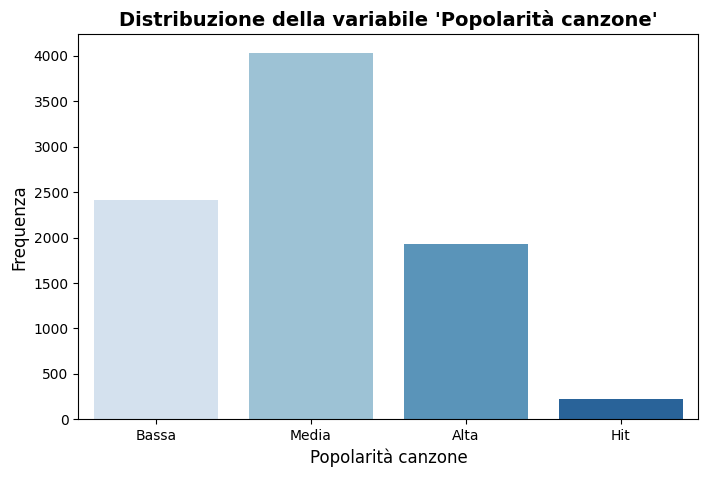

In [ ]:
# Grafico variabile Popolarità canzone (target)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Popolarità canzone',
              hue='Popolarità canzone', legend=False,
              palette='Blues')

plt.title("Distribuzione della variabile 'Popolarità canzone'", fontweight='bold', fontsize=14)
plt.xlabel('Popolarità canzone', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.show()

Da questo grafico possiamo notare che la maggior parte delle canzoni nel nostro dataset sono di popolarità media, mentre solo poche sono hit. Anche se a primo impatto può sembrare strano, in verità non lo è poiché solo poche canzoni diventano effettivamente delle hit. Ai fini del modello, per evitare problemi di classificazione errata, metteremo dei pesi alle classi, così che daremo un peso maggiore a quella minoritaria.

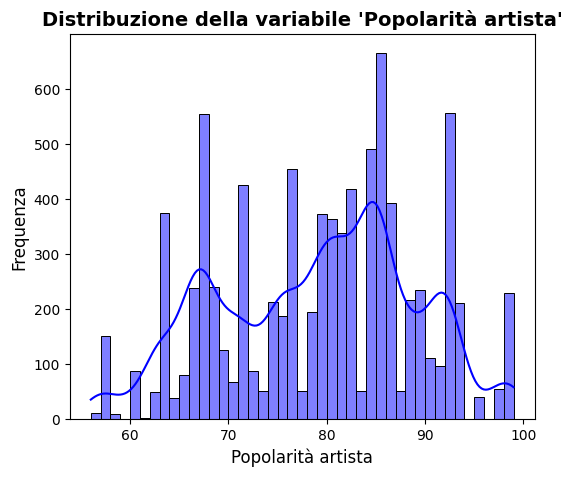

In [ ]:
# Grafico variabile Popolarità artista
plt.figure(figsize=(6, 5))
sns.histplot(df['Popolarità artista'], kde=True, binwidth=1, color='blue')

plt.title("Distribuzione della variabile 'Popolarità artista'", fontweight='bold', fontsize=14)
plt.xlabel('Popolarità artista', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.show()

Da questo grafico notiamo che ci sono diversi picchi, quindi gli artisti tendono a concentrarsi in gruppi di popolarità, come accade per il gruppo di popolarità 65-70 o per quello 85. Oltre a questo, i valori sull'asse delle x partono da, più o meno, 55, a significare che nel dataset non ci sono molti artisti poco popolari. Questo è in un certo senso giustificato in quanto nella ricerca abbiamo inserito solo artisti internazionali, quindi relativamente conosciuti, i quali tuttavia, non sempre fanno delle hit.

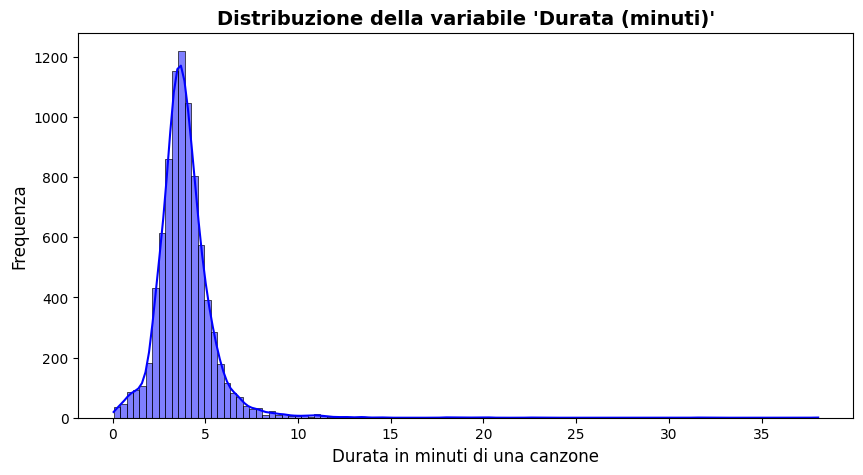

In [ ]:
# Grafico variabile Durata (minuti)
plt.figure(figsize=(10, 5))
sns.histplot(df['Durata (minuti)'], kde=True, color='blue', binwidth=0.35)

plt.title("Distribuzione della variabile 'Durata (minuti)'", fontweight='bold', fontsize=14)
plt.xlabel('Durata in minuti di una canzone', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.show()

Qui si nota invece una distribuzione fortemente asimmetrica, con una lunga cosa verso destra. Questo implica che ci sono delle canzoni che hanno una durata abbastanza lunga. Molto probabilmente si tratta di outliers, i quali verrano eliminati successivamente. Di fatto, è verosimile pensare che le tracce di durata superiore ai 40 minuti non siano delle canzoni, piuttosto possono essere eventi o altre tracce audio, motivo per il quale la futura eliminazione è giustificata.

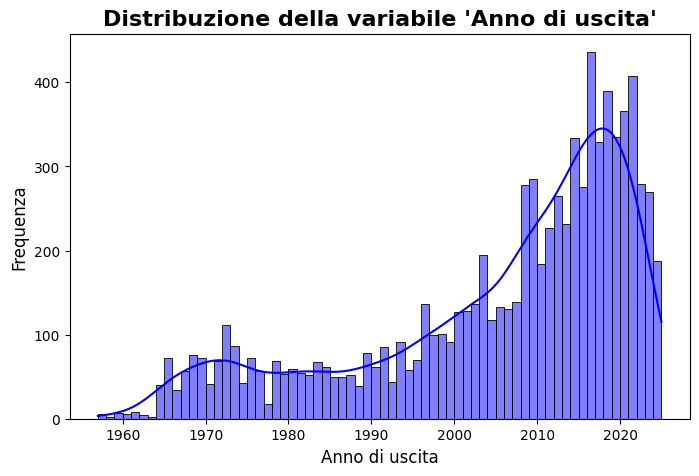

In [ ]:
# Grafico variabile Anno di uscita
plt.figure(figsize=(8, 5))
sns.histplot(df['Anno di uscita'], kde=True, color='blue', binwidth=1)

plt.title("Distribuzione della variabile 'Anno di uscita'", fontweight='bold', fontsize=16)
plt.xlabel('Anno di uscita', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.show()

Anche qui vediamo una distribuzione asimmetrica, con una densità maggiore a destra. Questo ci dice che nel nostro dataset ci sono poche canzone vecchie (soprattutto quelle degli anni 60). In questo caso però gli outlier non verranno eliminati, in quanto non rappresentano degli errori o delle versioni particolari delle canzoni. Sono semplicemente delle tracce datate, le quali devono restare.

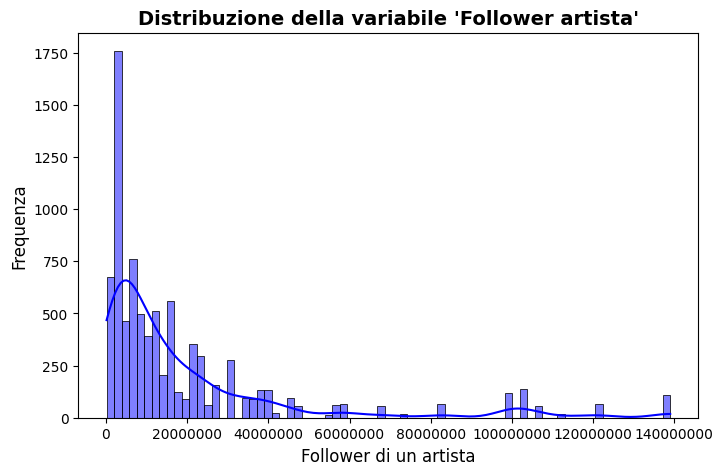

In [ ]:
# Grafico variabile Follower artista
plt.figure(figsize=(8, 5))
sns.histplot(df['Follower artista'], kde=True, color='blue')

plt.title("Distribuzione della variabile 'Follower artista'", fontweight='bold', fontsize=14)
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel('Follower di un artista', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.show()

Anche per questa variabile la distribuzione è fortmente asimmetrica, ma, come per il caso precedente, non sono valori da eliminare. Semplicemente è verosimile pensare che ci siano pochi artisti con un numero di follower molto alto e che invece ve ne siano molti con un numero di follower minore.

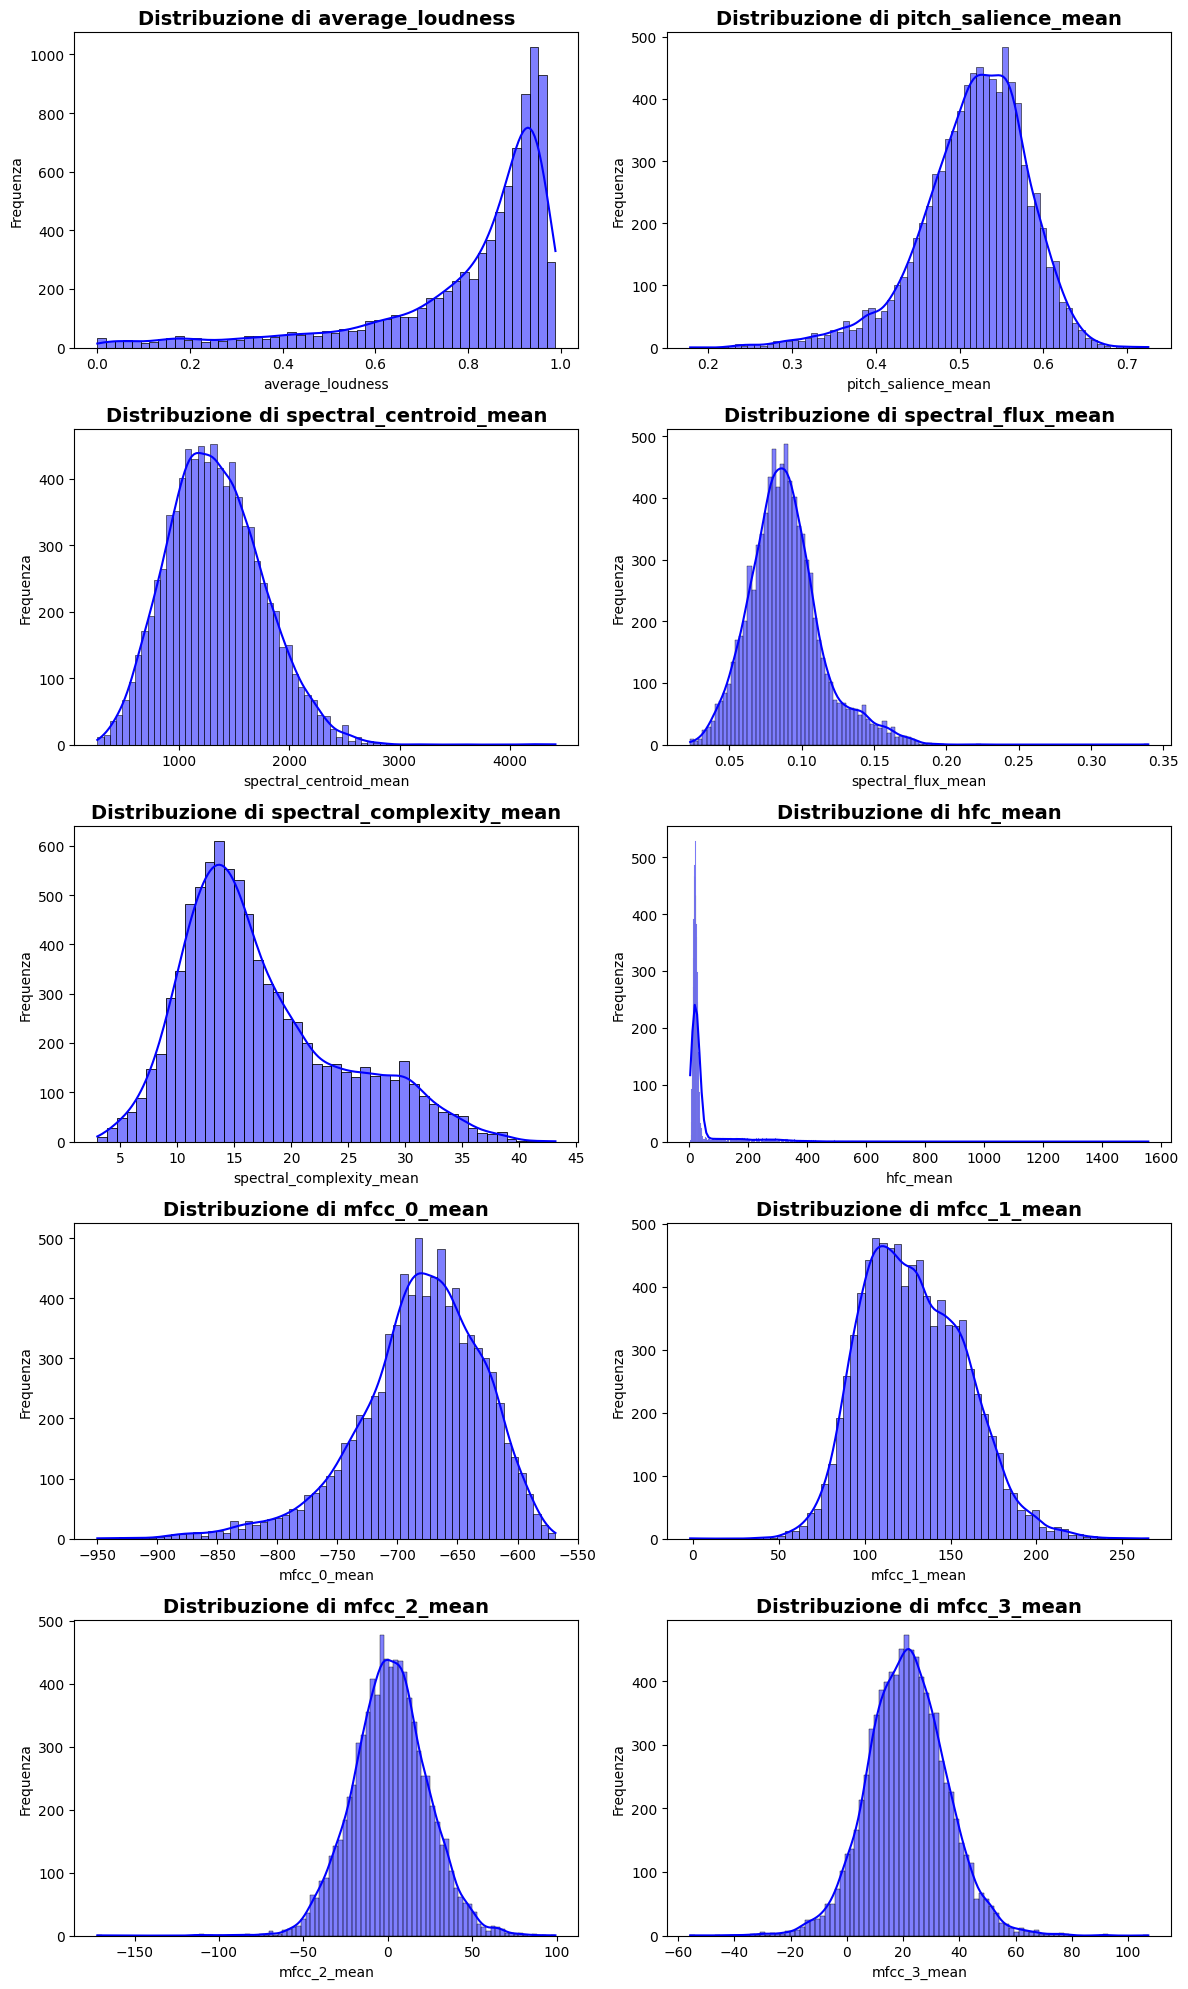

In [ ]:
# Grafici delle low-level features di una canzone
cols = ['average_loudness','pitch_salience_mean', 'spectral_centroid_mean',
        'spectral_flux_mean', 'spectral_complexity_mean', 'hfc_mean',
        'mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean']

n_cols = 2
n_rows = (len(cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, color='blue')
    axes[i].set_title(f'Distribuzione di {col}', fontweight='bold', fontsize=14)
    axes[i].set_ylabel('Frequenza')

plt.tight_layout()
plt.show()

Questi sopra sono i grafici delle low-level features. Ci danno informazioni utili su come esse sono distribuite. Anche se alcune distribuzioni risultano essere particolarmente asimmetriche, comunque non verranno toccate in quanto è probabile che alcune canzoni, poche, abbiano delle caratteristiche particolari.

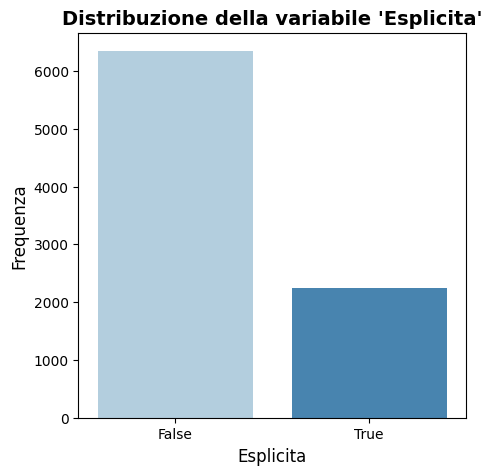

In [ ]:
# Grafico variabile Esplicita (si o no)
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='Esplicita (si o no)', hue='Esplicita (si o no)', palette='Blues', legend=False)

plt.title("Distribuzione della variabile 'Esplicita'", fontweight='bold', fontsize=14)
plt.xlabel('Esplicita', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.show()

La variabile esplicita ci dice se il testo di una canzone è esplicito oppure no. Nel nostro caso, la maggior parte delle canzoni sono non esplicite.

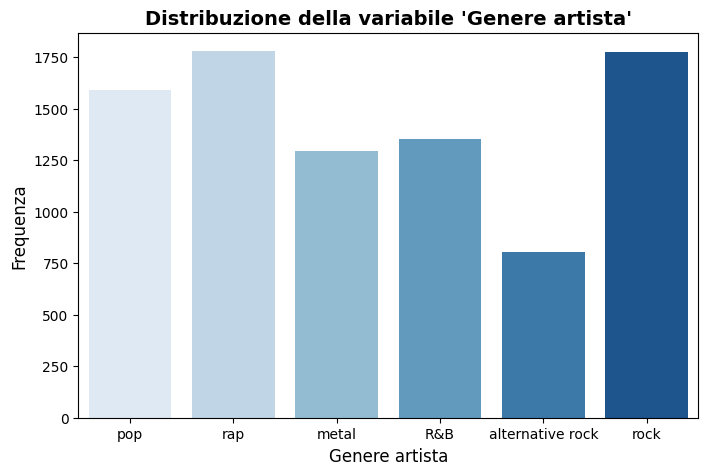

In [ ]:
# Grafico variabile Genere artista
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Genere artista', hue='Genere artista', palette='Blues')

plt.title("Distribuzione della variabile 'Genere artista'", fontweight='bold', fontsize=14)
plt.xlabel('Genere artista', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.show()

I generi musicali sembrano essere distribuiti equamente, quindi le canzoni coprono bene tutti i generi. Bisogna specificare che metal e alternative rock sono sottogenenri del rock, quindi possiamo dire che nel dataset c'è forse una quantita maggiore di canzoni rock.

#### Identificazione ed eliminazione outliers

Riassumendo quanto visto, dall'osservazione dei grafici precedenti emerge che alcune variabili presentano distribuzioni caratterizzate da code lunghe e sottili, suggerendo la possibile presenza di outlier. Tuttavia, l'unica variabile su cui si è deciso di intervenire è quella relativa alla Durata in minuti di una canzone, la cui distribuzione mostra una coda lunga verso destra, indicativa di brani con durate eccezionalmente elevate.

La motivazione alla base della rimozione degli outlier per questa variabile è legata alla presenza di canzoni dalla durata anche superiore ai 40 minuti. Tali valori non costituiscono errori di inserimento, ma verosimilmente rappresentano versioni particolari (ad esempio live, estese o medley) oppure brani non assimilabili a vere e proprie canzoni nel contesto analizzato. In tal senso, l'eliminazione si giustifica con l'intento di evitare che questi valori, statisticamente marginali ma estremi, influenzino negativamente le analisi successive.

Per quanto riguarda le altre variabili, pur in presenza di code distribuzionali simili, non si è proceduto alla rimozione di alcun valore. In questi casi, infatti, i valori estremi non rappresentano anomalie né casi atipici, ma osservazioni rare che sono tuttavia del tutto plausibili. Un esempio è la variabile 'hcf_mean', che descrive una caratteristica acustica delle canzoni: sebbene presenti valori poco frequenti, essi riflettono effettive peculiarità del contenuto audio e non devono essere considerati errati o anomali.

In [ ]:
Q1 = df['Durata (minuti)'].quantile(0.25)
Q3 = df['Durata (minuti)'].quantile(0.75)
IQR = Q3 - Q1

filtro = (df['Durata (minuti)'] >= Q1 - 1.5 * IQR) & (df['Durata (minuti)'] <= Q3 + 1.5 * IQR)

df= df[filtro]

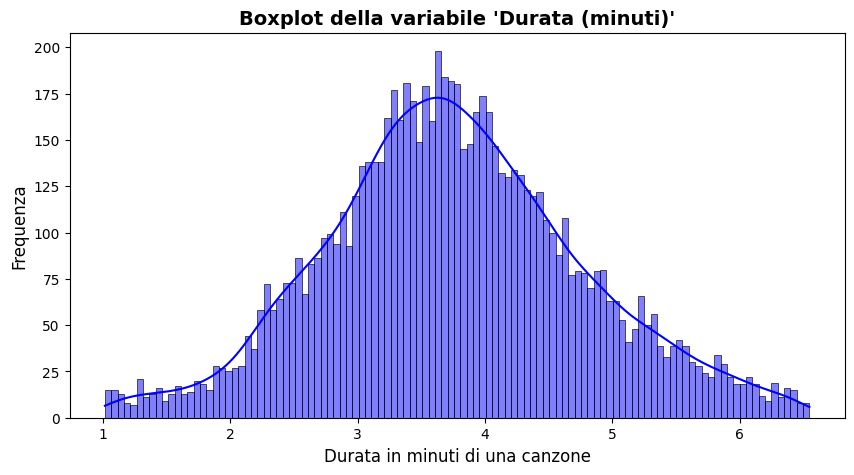

In [ ]:
# Grafico variabile Durata (minuti)
plt.figure(figsize=(10, 5))
sns.histplot(df['Durata (minuti)'], kde=True, color='blue', binwidth=0.05)

plt.title("Boxplot della variabile 'Durata (minuti)'", fontweight='bold', fontsize=14)
plt.xlabel('Durata in minuti di una canzone', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.show()

Come possiamo notare ora l'effetto degli outliers è sparito.

In [ ]:
print(f"Dopo l' eliminazione degli outliers il dataset ha dimensione {df.shape}")

Dopo l' eliminazione degli outliers il dataset ha dimensione (8119, 17)


### Analisi multivariata

A questo punto, possiamo fare un'analisi multivariata per vedere se c'è una forte correlazione tra variabili e valutare quindi se quelle fortemente correlate possono essere eliminate. Questo in quanto se una variabile è molto correlata (sia positivamente che negativamente) con un'altra, è come se ci dessero la stessa informazioni, quindi tenerle entrambe appesantisce il modello e basta. Come soglia critica oltre la quale valutare l'eliminazione è stata scelta 0.90 (-0.90).

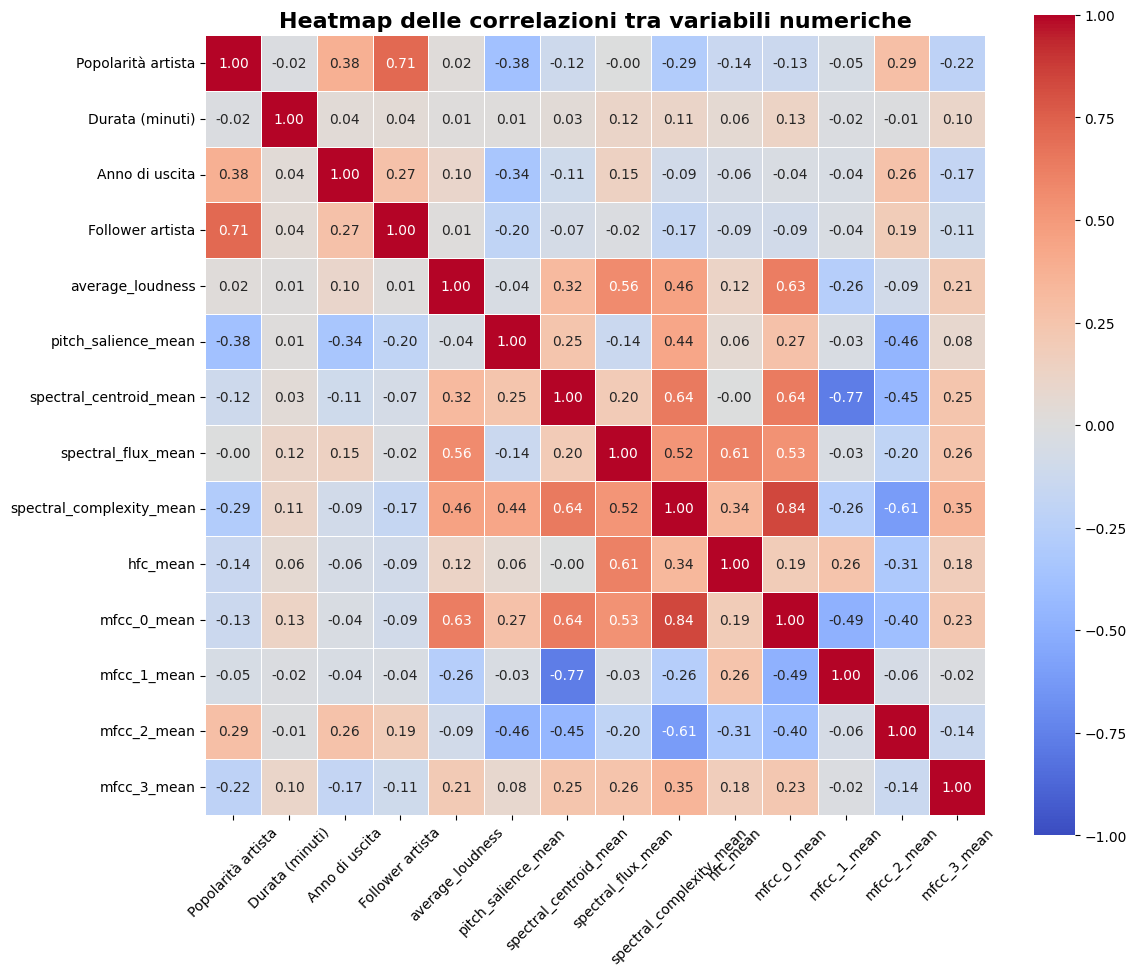

In [ ]:
# Heatmap delle correlazioni tra variabili numeriche
df_num = df.select_dtypes(include=('int64', 'float64'))

corr_matrix = df_num.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True)

plt.title('Heatmap delle correlazioni tra variabili numeriche', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Dall'analisi dell'heatmap emerge che alcune variabili presentano livelli di correlazione piuttosto elevati (ad esempio 0.84 o -0.77). Tuttavia, abbiamo deciso di non eliminarle, poiché non superano la soglia critica da noi stabilita, fissata a 0.90.

Inoltre, è importante sottolineare che alcune delle variabili considerate (in particolare quelle che rappresentano low-level features) sono intrinsecamente correlate tra loro, in quanto descrivono caratteristiche acustiche della stessa canzone. Sebbene vi sia una certa ridondanza informativa, non è opportuno rimuoverle, poiché ognuna di esse fornisce un contributo distintivo nella rappresentazione del brano dal punto di vista audio.

Un discorso a parte riguarda le variabili "Popolarità artista" e "Follower artista", che mostrano una correlazione pari a 0.71. Pur trattandosi di un valore relativamente alto, riteniamo che non sia sufficientemente elevato da giustificare l'eliminazione di una delle due, poiché entrambe veicolano informazioni potenzialmente utili e complementari nel contesto della nostra analisi.

### Analisi bivariata

A questo punto possiamo fare anche delle analisi molto interessanti, le quali ci possono dare informazioni importanti sulla relazione che sussiste tra due variabili.

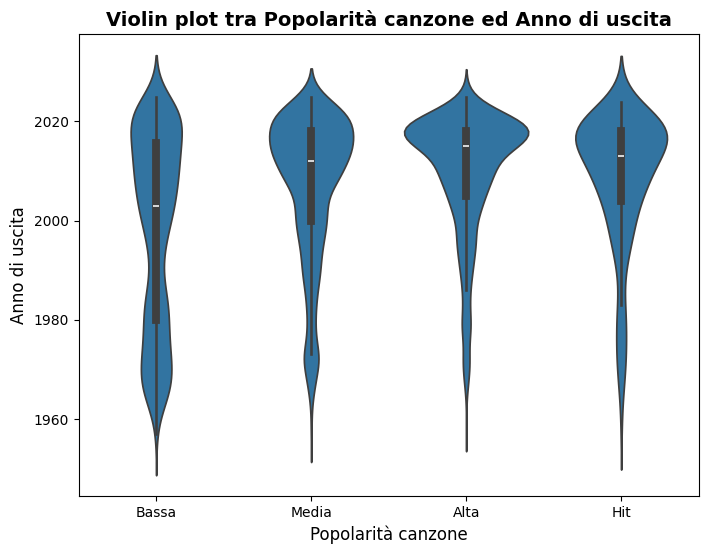

In [ ]:
# Grafico tra la Target e l'anno di uscita
plt.figure(figsize=(8,6))
sns.violinplot(data=df, x='Popolarità canzone', y='Anno di uscita')
plt.title('Violin plot tra Popolarità canzone ed Anno di uscita', fontweight='bold', fontsize=14)
plt.xlabel('Popolarità canzone', fontsize=12)
plt.ylabel('Anno di uscita', fontsize=12)
plt.show()

Da questo grafico possiamo capire delle informazioni interessanti. Notiamo come prima cosa che la mediana (linea bianca orizzontale) tende a crescere sensibilmente, segno del fatto che la popolarità è più alta tra le canzoni nuove. Oltre a questo notiamo che tra le tracce con popolarità bassa, spiccano le canzone più vecchie. Questo probabilmente è dovuto al fatto che alcune canzoni molto datate, seppure molto famose al tempo in cui uscirono, al giorno d'oggi sono meno popolari. Una possibile motivazione è che la feature è presa da Spotify, piattaforma relativamente recente, o ancora un'altra motivazione può essere che ad oggi si ascoltano maggiormente canzoni recenti, e quindi quest'ultime saranno maggiormente popolari.

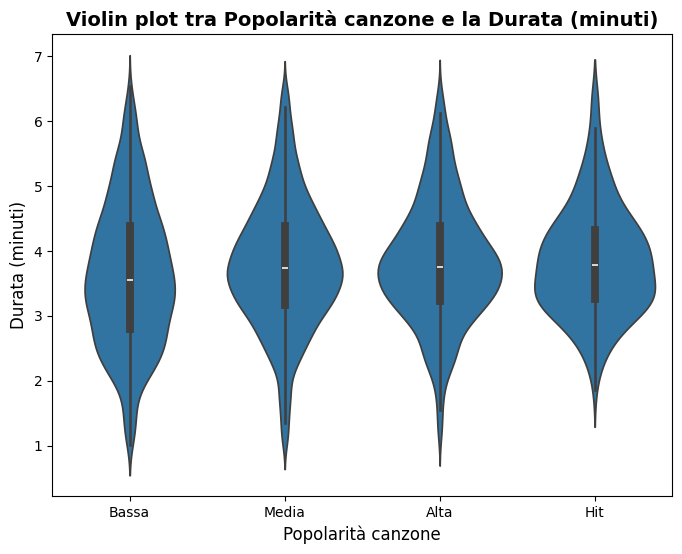

In [ ]:
# Grafico tra la Target e la durata in minuti di una canzone
plt.figure(figsize=(8,6))
sns.violinplot(data=df, x='Popolarità canzone', y='Durata (minuti)')
plt.title('Violin plot tra Popolarità canzone e la Durata (minuti)', fontweight='bold', fontsize=14)
plt.xlabel('Popolarità canzone', fontsize=12)
plt.ylabel('Durata (minuti)', fontsize=12)
plt.show()

Qui possiamo notare che le canzoni si concentrano principalmente su una durata che va dai 3 ai 4 minuti, indipendentemente dalla classe di popolarità di appartenenza.

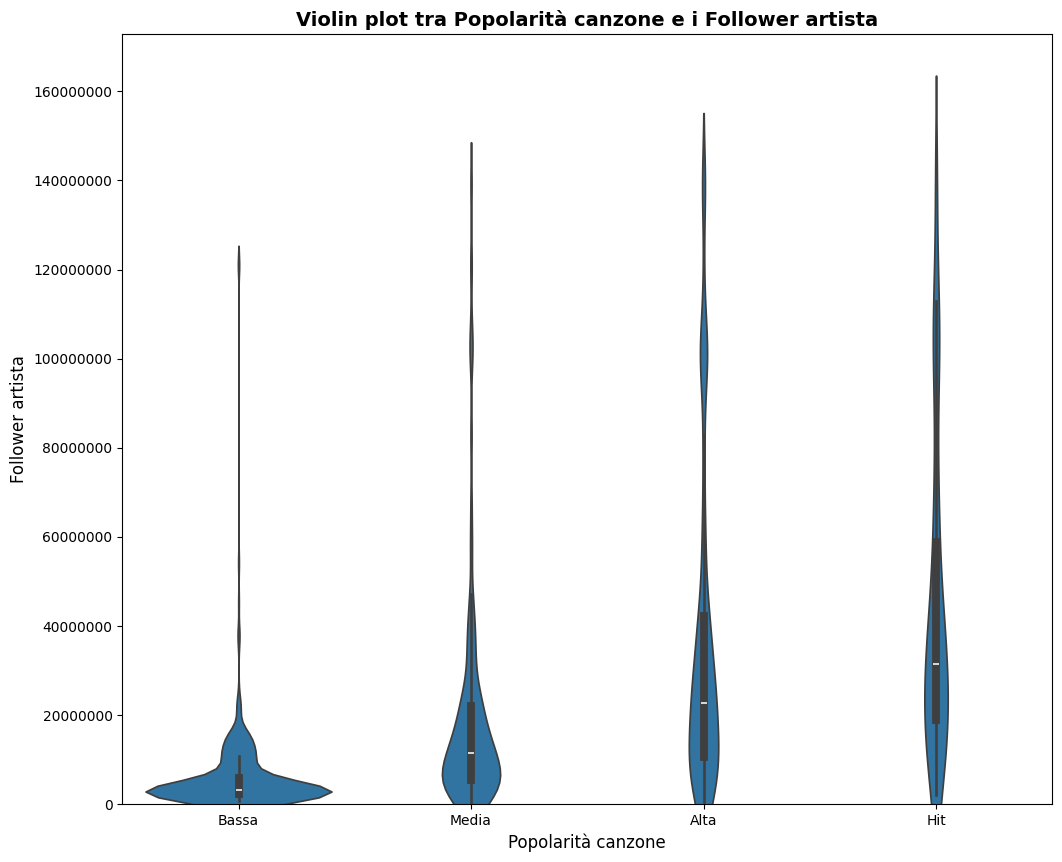

In [ ]:
# Grafico tra la Target e i follower di un'artista
plt.figure(figsize=(12,10))
sns.violinplot(data=df, x='Popolarità canzone', y='Follower artista')
plt.title('Violin plot tra Popolarità canzone e i Follower artista', fontweight='bold', fontsize=14)
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(bottom=0)
plt.xlabel('Popolarità canzone', fontsize=12)
plt.ylabel('Follower artista', fontsize=12)
plt.show()

Questo grafico ci mostra invece un risultato che ci aspettavamo, ossia che con l'aumentare dei follower di un artista, la popolarità di una canzone tende ad essere maggiore. Lo si può notare dalla mediana, che tende ad aumentare con l'aumento della popolarità.

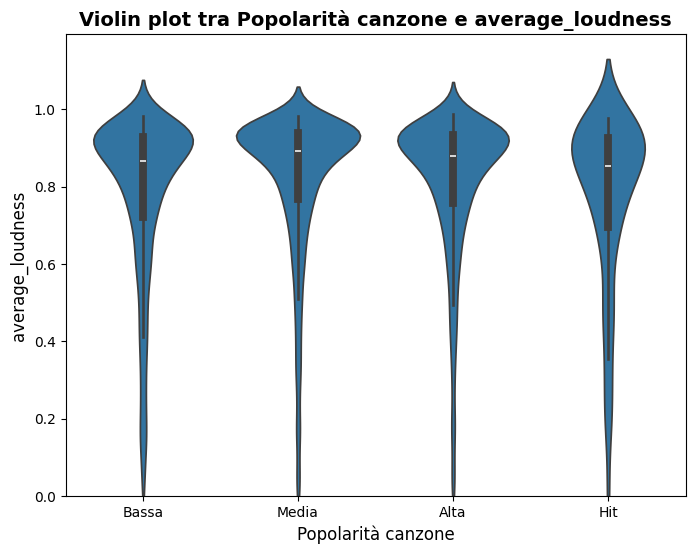

In [ ]:
# Grafico tra la Target e l'average loudness
plt.figure(figsize=(8,6))
sns.violinplot(data=df, x='Popolarità canzone', y='average_loudness')
plt.title('Violin plot tra Popolarità canzone e average_loudness', fontweight='bold', fontsize=14)
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(bottom=0)
plt.xlabel('Popolarità canzone', fontsize=12)
plt.ylabel('average_loudness', fontsize=12)
plt.show()

Qui possiamo invece notare come l'average loudness sia più o meno la stessa, indipendentemente dalla popolarità di una canzone.

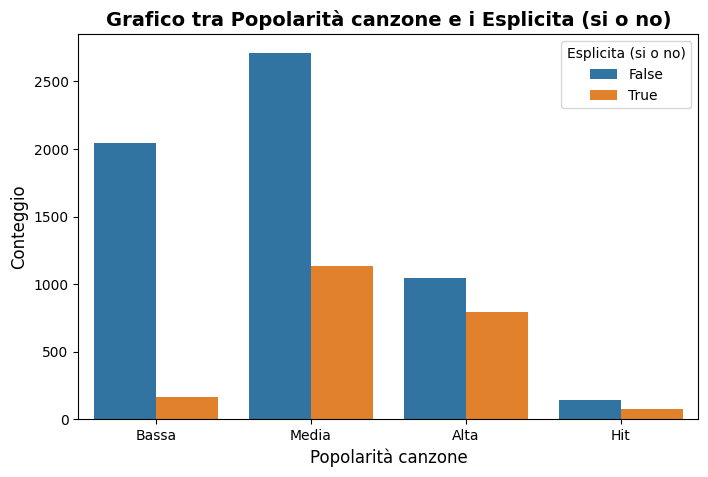

In [ ]:
# Grafico tra la Target e l'esplicità di una canzone
pd.crosstab(df['Popolarità canzone'], df['Esplicita (si o no)'], normalize='index')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Popolarità canzone', hue='Esplicita (si o no)')
plt.title('Grafico tra Popolarità canzone e i Esplicita (si o no)', fontweight='bold', fontsize=14)
plt.xlabel('Popolarità canzone', fontsize=12)
plt.ylabel('Conteggio', fontsize=12)
plt.show()

Qui notiamo un dato interessante. Sappiamo già dal grafico univariato fatto precedentemente, che la variabile esplicita ha una prevalenza di canzoni non esplicite, e questo lo vediamo anche in questo grafico, dove la colonna blu che rappresenta le canzoni non esplicite è sempre quella più alta. Ciò che però risulta interessante è la proporzione tra le due. Se notiamo, quasi tutte le canzoni con una popolarità bassa risultano avere un testo non esplicito, risultato che si attenua andando avanti, fino ad arrivare alle popolarità alta e hit. In questi ultimi casi, le canzoni con un testo esplcite sono, in proporzione, maggiori rispetto ai casi precedenti, dato che indica che, tra le canzoni più popolari, sono presenti in buona quantità anche quelle che hanno un testo esplicito, a differenza di quelle meno popolari.

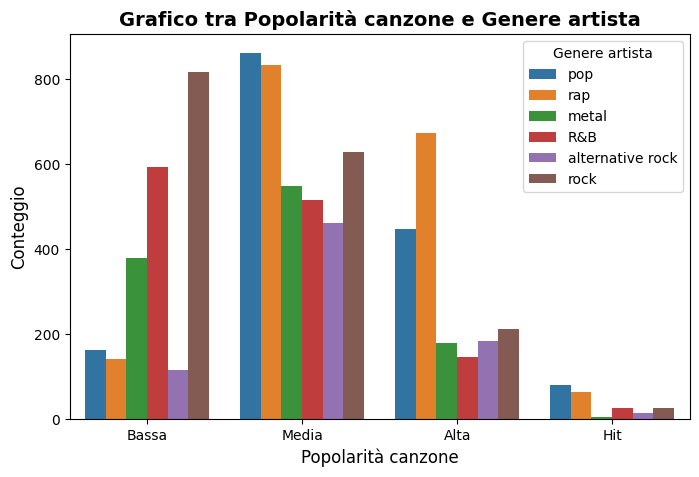

In [ ]:
# Grafico tra la Target ed il Genere artista
pd.crosstab(df['Popolarità canzone'], df['Genere artista'], normalize='index')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Popolarità canzone', hue='Genere artista')
plt.title('Grafico tra Popolarità canzone e Genere artista', fontweight='bold', fontsize=14)
plt.xlabel('Popolarità canzone', fontsize=12)
plt.ylabel('Conteggio', fontsize=12)
plt.show()

Da questo grafico possiamo vedere come i generi variano in base alla popolarità di una canzone. Notiamo che tra le canzoni con popolarità bassa, risultano esserci molte canzoni rock e R&B. Andando avanti con la popolarità possiamo notare come i generi che la fanno da padrone sono il pop ed il rap. Questo risultato a primo impatto può far pensare che il rock sia un genere associato ad una bassa popolarità, tuttavia, non è corretto. Per comprenderne il motivo basta osservare il prossimo grafico.

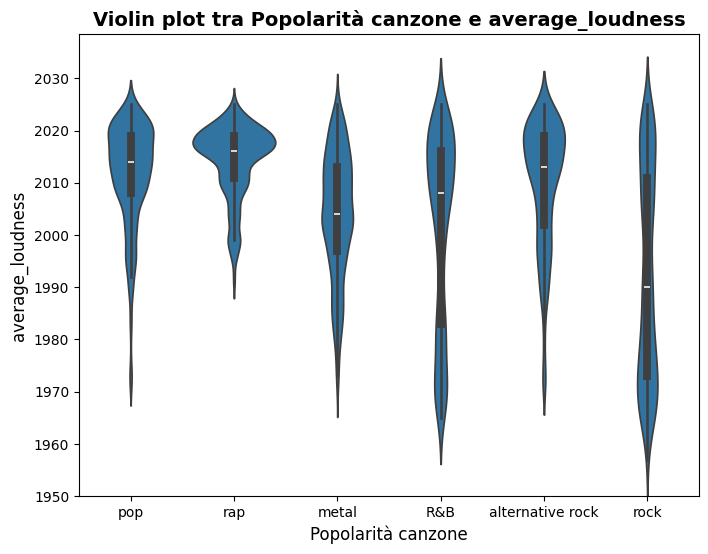

In [ ]:
# Grafico tra il genere e la data di uscita
plt.figure(figsize=(8,6))
sns.violinplot(data=df, x='Genere artista', y='Anno di uscita')
plt.title('Violin plot tra Popolarità canzone e average_loudness', fontweight='bold', fontsize=14)
plt.ylim(bottom=1950)
plt.xlabel('Popolarità canzone', fontsize=12)
plt.ylabel('average_loudness', fontsize=12)
plt.show()

Questo grafico mette in relazione il genere con la data di uscita. Come notiamo, il rock non è realmente un genere associato a canzoni con bassa popolarità, o meglio, non tanto quanto appare dal grafico precedente. Semplicemente notiamo che nel dataset, la maggior parte delle canzoni vecchie, che ricordiamo sono quelle con la popolarità più bassa, sono rock. Questo ragionamento non si applica con altri generi. Per esempio il genere R&B risulta essere effettivamente meno popolare degli altri.

# Pre-processing dei dati

A questo punto abbiamo completato l'analisi esplorativa dei dati, quindi ora possiamo concentrarci sul pre-processing così da raffinarli per il modello. Come prima cosa importiamo le librerie che useremo.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

A questo punto dobbiamo codificare le variabili categoriche. Per la feature Genere artista possiamo usare delle semplici dummies, mentre per la target usiamo un label encoding.

In [ ]:
# One-hot encoding della feature categorica
df_encoded = pd.get_dummies(df, columns=['Genere artista'], drop_first=False)

# Separazione X (features) e y (target)
X = df_encoded.drop('Popolarità canzone', axis=1)
y = df_encoded['Popolarità canzone']

# Label encoding della target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

A questo punto possiamo dividere il dataset in training set e validation set. Per la divisione diamo il 60% delle osservazioni al training set ed il al validation set. La parte restante viene usata per il calibration set.

In [ ]:
# Divido direttamente in train, calibrazione e validazione
X_temp, X_val, y_temp, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_calib, y_train, y_calib = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

In [ ]:
print(f"Il training set ha un numero di osservazioni pari a: {X_train.shape[0]}.")
print(f"Il validation set ha un numero di osservazioni pari a: {X_val.shape[0]}.")
print(f"Le classi nella target sono: {le.classes_}")

Il training set ha un numero di osservazioni pari a: 4871.
Il validation set ha un numero di osservazioni pari a: 1624.
Le classi nella target sono: ['Alta' 'Bassa' 'Hit' 'Media']


Normalizzo le variabili continue in quanto hanno dei range di valori molto diversi tra di loro.

In [ ]:
# Seleziona solo le colonne numeriche da normalizzare
numerical_features = ['Popolarità artista', 'Durata (minuti)', 'Anno di uscita',
                      'Follower artista', 'average_loudness', 'pitch_salience_mean',
                      'spectral_centroid_mean', 'spectral_flux_mean', 'spectral_complexity_mean',
                      'hfc_mean', 'mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean']

# Inizializza lo scaler
scaler = StandardScaler()

# Fit solo sul training set
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_val_scaled[numerical_features] = scaler.transform(X_val[numerical_features])

X_calib_scaled = X_calib.copy()
X_calib_scaled[numerical_features] = scaler.transform(X_calib[numerical_features])

# Modello

A questo punto possiamo costruire il modello.

A questo punto possiamo costruire il modello che abbiamo scelto. Inizialmente abbiamo provato con delle reti neurali, ma le dimensioni e la struttura del dataset ci hanno consigliato che altri modelli, come quelli ensemble, performano meglio in questo caso. Per questo motivo abbiamo scelto di usare una random forest.
Gli algoritmi delle random forest hanno tre iperparametri principali, che devono essere impostati prima dell'addestramento. Tra questi rientrano la dimensione del nodo, il numero di alberi e il numero di funzioni campionate. Da lì, il classificatore della foresta casuale può essere utilizzato per risolvere problemi di regression o classificazione.
L'algoritmo random forest è costituito da una raccolta di decision trees e ogni albero dell'insieme è composto da un campione di dati tratto da un set di addestramento con sostituzione, chiamato Bootstrapping. Di quel campione di allenamento, un terzo viene accantonato come dati di test, noti come campione out-of-bag (oob). Un altro esempio di casualità viene poi immesso attraverso il feature bagging, aggiungendo maggiore diversità al set di dati e riducendo la correlazione tra decision trees. A seconda del tipo di problema, la determinazione della previsione varierà. Per un'attività di regressione, verrà calcolata la media dei singoli decision trees e per un'attività di classificazione, un voto di maggioranza (ovvero la variabile categorica più frequente) produrrà la classe prevista.

In [ ]:
# 1. Inizializza il modello
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42
)

# 2. Addestra il modello
model.fit(X_train, y_train)

# 3. Previsioni
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# 4. Calcola le accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# 5. Stampa i risultati
print(f"Accuracy sui dati di TRAINING:   {train_accuracy:.4f}")
print(f"Accuracy sui dati di VALIDATION: {val_accuracy:.4f}")

Accuracy sui dati di TRAINING:   0.7304
Accuracy sui dati di VALIDATION: 0.6219


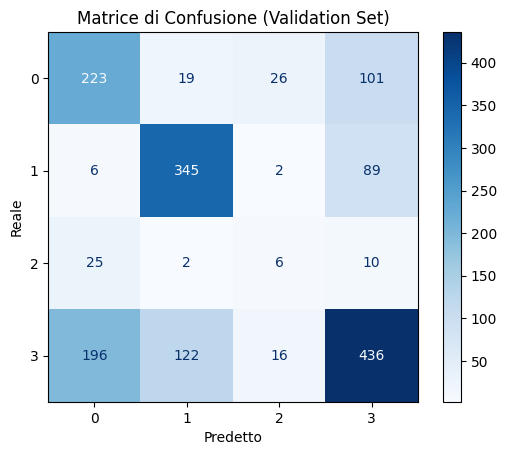

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calcola la matrice di confusione
cm = confusion_matrix(y_val, y_val_pred)

# 2. Visualizza la matrice
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Matrice di Confusione (Validation Set)")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.grid(False)
plt.show()

Come possiamo notare, la classe 2, ossia la hit, non viene prevista molto bene, anzi, viene prevista malissimo. Abbiamo provato a personalizzare i pesi, ma non c’è stato verso di migliorare la situazione.
Nel complesso possiamo dire che il modello non è ottimo per le finalità del progetto, ossia quella di prevedere proprio se una canzone è una hit oppure no. L’unico modo per poter risolvere la situazione era quello di fare delle modifiche strutturali molti importanti al dataset, le quali, per motivazioni di tempo, non siamo riusciti a fare (per esempio considerare un problema binario, hit se la popolarità è maggiore di 50, flop in caso contrario).


# Conformal prediction

A questo punto, una volta addestrato il modello e fatto le previsioni, possiamo usare la conformal prediction per avere una misura dell’incertezza delle previsioni stesse.
La Conformal Prediction è una tecnica statistica che, dato un modello di classificazione o regressione, permette di associare ad ogni input un insieme di predizioni plausibili (anziché una singola classe o un singolo valore), con una garanzia di copertura: ovvero, con alta probabilità la vera risposta è contenuta in quell’insieme. In classificazione, il risultato sarà un sottoinsieme di classi. L’obiettivo è che la vera classe sia contenuta nel prediction set almeno nel (1−α)% dei casi.
Questa tecnica si basa su:
-	La costruzione di nonconformity scores, cioè misure che indicano quanto ciascuna predizione si discosta da quella corretta.
-	Un set di calibrazione (diverso dal training e validation set).

In [ ]:
# Calcolo i "nonconformity scores" sul calibration set
# Definizione: score = 1 - probabilità della vera classe
probs_calib = model.predict_proba(X_calib)
# Indici delle classi vere
indices_true_class = [np.where(model.classes_ == c)[0][0] for c in y_calib]
# Score di non conformità (quanto il modello è incerto sulla vera classe)
nonconformity_scores = 1 - probs_calib[np.arange(len(y_calib)), indices_true_class]

# Livello di confidenza (es. 90% = alpha=0.1)
alpha = 0.1
q = np.quantile(nonconformity_scores, 1 - alpha, interpolation='higher')

# Funzione per costruire il set di predizione conformal per un singolo esempio
def conformal_set(probs, q):
    return np.array([model.classes_[i] for i, p in enumerate(probs) if 1 - p <= q])

# Calcolo dei conformal set per il validation set
probs_val = model.predict_proba(X_val)

prediction_sets = [conformal_set(p, q) for p in probs_val]

# Analisi dei risultati
# Es: guarda i primi 10 conformal sets
for i in range(10):
  input_row = X_val.iloc[[i]]  # Assumo che X_val sia ancora un DataFrame
  model_pred = model.predict(input_row)[0]
  true_class = y_val[i]        # <-- CORRETTO
  conformal_set = prediction_sets[i]
  print(f"Input {i}: Conformal set = {conformal_set}, True class = {true_class}")



# Valutazione dell'accuracy classica (singola predizione)
y_val_pred = model.predict(X_val)
print("Accuracy classica validation:", accuracy_score(y_val, y_val_pred))

# Verifica coverage empirica:
# Quante volte la vera classe è nel conformal set? (dovrebbe essere >= 1 - alpha)
coverage = np.mean([y_val[i] in prediction_sets[i] for i in range(len(y_val))])

print(f"Coverage empirica (should be >= {1-alpha}): {coverage:.3f}")

Input 0: Conformal set = [0 2], True class = 0
Input 1: Conformal set = [1], True class = 1
Input 2: Conformal set = [1 3], True class = 1
Input 3: Conformal set = [1], True class = 1
Input 4: Conformal set = [1 3], True class = 3
Input 5: Conformal set = [1 3], True class = 3
Input 6: Conformal set = [0 1 3], True class = 0
Input 7: Conformal set = [0 1 3], True class = 3
Input 8: Conformal set = [0 3], True class = 3
Input 9: Conformal set = [0 3], True class = 1
Accuracy classica validation: 0.6219211822660099
Coverage empirica (should be >= 0.9): 0.901


Nei risultati della conformal prediction possiamo notare che sono pochi gli insiemi di piccole dimensioni. Questo potevamo aspettarcelo in quanto il modello ha un'accuratezza bassa e quindi la conformal riflette tutta l'incertezza del modello. Ciò che conta però è che siamo riusciti a superare la soglia fissata, ossia il 90%; questo indica che la conformal prediction nel 90% dei casi contiene nell'insieme di predizione la classe corretta.